In [1]:
#Required for cellpose
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io
from cellpose.io import imread

io.logger_setup()

model = models.CellposeModel(gpu=True)

[GUI INFO] : WRITING LOG OUTPUT TO C:\Users\esthe\.cellpose\run.log

cellpose version: 	4.2.1.1 
platform:       	win32 
python version: 	3.11.15 
torch version:  	2.12.1+cu126
2026-08-23 16:31:40,988 [io INFO] WRITING LOG OUTPUT TO C:\Users\esthe\.cellpose\run.log
2026-08-23 16:31:40,988 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	win32 
python version: 	3.11.15 
torch version:  	2.12.1+cu126
2026-08-23 16:31:41,267 [core INFO] ** TORCH CUDA version installed and working. **
2026-08-23 16:31:41,269 [core INFO] >>>> using GPU (CUDA)
2026-08-23 16:31:43,042 [models INFO] >>>> loading model C:\Users\esthe\.cellpose\models\cpsam_v2


In [2]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.12.1+cu126
True
NVIDIA GeForce RTX 3070 Laptop GPU


In [3]:
#For other convienient functions
import os
import tifffile
from cellpose import transforms

import csv
from cellpose import plot

In [4]:
toffy_base_dir = r"c:/Users/esthe/Documents/toffy"
cohort_subdir = r"Cohorts/2026Aug_renormalized/image_data"
data_dir = os.path.join(toffy_base_dir, cohort_subdir)
fovs = os.listdir(data_dir)

cellpose_dir = r"C:/Users/esthe/Documents/cellposev4"
output_dir = os.path.join(cellpose_dir, "output")
os.makedirs(output_dir,exist_ok = True )

membrane_channels = ["EpCAM", "CD45", "HLA Class 1, ABC"]
nuclei_channels = ["dsDNA_Histone H3"]


In [5]:
def stack_channels(fov_channel_files, channel_list):
    """Load selected channels, normalize with Cellpose normalize99, and sum."""
    imgs = []

    for ch in channel_list:
        if ch in fov_channel_files:
            img = io.imread(str(fov_channel_files[ch])).astype(np.float32)
            imgs.append(transforms.normalize99(img))

    if not imgs:
        return None

    return np.sum(np.stack(imgs, axis=0), axis=0).astype(np.float32)


In [6]:
#set parameters for cellpose
flow_threshold = 0.5
cellprob_threshold =-1
tile_norm_blocksize = 100
masks_ext = ".tiff"



In [ ]:
#Test

test_fov = os.path.join(data_dir, fovs[100])
test_channel_files = {
    os.path.splitext(f)[0]: os.path.join(test_fov, f)
    for f in os.listdir(test_fov)
    if f.lower().endswith((".tif", ".tiff"))
}
mem_img = stack_channels(test_channel_files, membrane_channels)
nuc_img = stack_channels(test_channel_files, nuclei_channels)
whole_img = np.stack([mem_img, nuc_img], axis=-1)


masks, flows, styles = model.eval(whole_img,
                                  augment=True, 
                                  batch_size=4, 
                                  flow_threshold=flow_threshold, 
                                  cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize},
                                  niter=100,
                                  )
#io.imsave(os.path.join(output_dir, f"{test_fov}_masks{masks_ext}"),masks,)

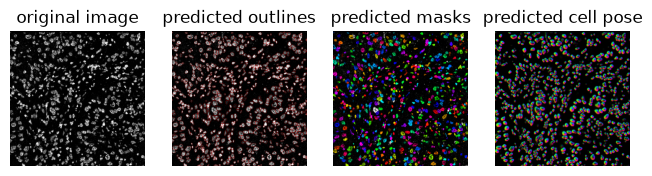

In [ ]:

plt.figure(figsize=(8,8))
plot.show_segmentation(
    fig=plt.gcf(),
    img=whole_img,
    maski=masks,
    flowi=flows[0],
)
plt.show()

In [14]:
from tqdm.auto import tqdm

ark_mask_dir = os.path.join(output_dir, "Ark_mask")
os.makedirs(ark_mask_dir, exist_ok=True)

summary = []
for fov in tqdm(fovs):
    fov_dir = os.path.join(data_dir, fov)
    channel_files = {
        os.path.splitext(f)[0]: os.path.join(fov_dir, f)
        for f in os.listdir(fov_dir)
        if f.lower().endswith((".tif", ".tiff"))
    }
    mem_img = stack_channels(channel_files, membrane_channels)
    nuc_img = stack_channels(channel_files, nuclei_channels)
    whole_img = np.stack([mem_img, nuc_img], axis=-1)

    masks, flows, styles = model.eval(whole_img,
                                      augment=True, 
                                      batch_size=2, 
                                      flow_threshold=flow_threshold, 
                                      cellprob_threshold=cellprob_threshold,
                                      normalize={"tile_norm_blocksize": tile_norm_blocksize},
                                      niter=100,
                                      )
    io.imsave(
        os.path.join(output_dir, f"{fov}_cell_mask{masks_ext}"),
        masks,
    )

    #Ark compatible masks
    ark_mask_path = os.path.join(ark_mask_dir, f"{fov}_ark_mask{masks_ext}")
    tifffile.imwrite(
        os.path.join(ark_mask_path),
        masks.astype(np.uint16),
    )

    #summary metrics
    summary.append({
        "fov": fov,
        "num_cells": np.max(masks),
        "num_pixels": np.sum(masks > 0),
        "path" : ark_mask_path
    })



with open(os.path.join(output_dir, "segmentation_summary.csv"),
          "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["fov", "num_cells", "num_pixels", "path"]
    )
    writer.writeheader()
    writer.writerows(summary)



  0%|          | 0/178 [00:00<?, ?it/s]

In [11]:
#For nucleus mask
from tqdm.auto import tqdm
ark_mask_dir = os.path.join(output_dir, "Ark_mask")
os.makedirs(ark_mask_dir, exist_ok=True)

summary = []
for fov in tqdm(fovs):
    fov_dir = os.path.join(data_dir, fov)
    channel_files = {
        os.path.splitext(f)[0]: os.path.join(fov_dir, f)
        for f in os.listdir(fov_dir)
        if f.lower().endswith((".tif", ".tiff"))
    }
    mem_img = stack_channels(channel_files, membrane_channels)
    nuc_img = stack_channels(channel_files, nuclei_channels)
    whole_img = np.stack([mem_img, nuc_img], axis=-1)

    masks, flows, styles = model.eval(nuc_img,
                                      augment=True, 
                                      batch_size=2, 
                                      flow_threshold=flow_threshold, 
                                      cellprob_threshold=cellprob_threshold,
                                      normalize={"tile_norm_blocksize": tile_norm_blocksize},
                                      niter=100,
                                      )
    io.imsave(
        os.path.join(output_dir, f"{fov}_nuc_mask{masks_ext}"),
        masks,
    )

    #Ark compatible masks
    ark_mask_path = os.path.join(ark_mask_dir, f"{fov}_nuc_mask{masks_ext}")
    tifffile.imwrite(
        os.path.join(ark_mask_path),
        masks.astype(np.uint16),
    )

    #summary metrics
    summary.append({
        "fov": fov,
        "num_cells": np.max(masks),
        "num_pixels": np.sum(masks > 0),
        "path" : ark_mask_path
    })



with open(os.path.join(output_dir, "segmentation_summary.csv"),
          "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["fov", "num_cells", "num_pixels", "path"]
    )
    writer.writeheader()
    writer.writerows(summary)



  0%|          | 0/178 [00:00<?, ?it/s]